In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchaudio
import torchaudio.transforms as T
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import wave

# Setting up the device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Manual seed for reproducibility - crucial for internship evaluations
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cuda


In [2]:
!nvidia smi

'nvidia' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import os
import pandas as pd

# Path to the main folder
base_path = "gunshot-audio-dataset"
data_list = []

# Crawling through the folders to get full paths
for class_folder in os.listdir(base_path):
    class_path = os.path.join(base_path, class_folder)
    
    # Check if it's a directory to skip any loose files
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        print(f"Found {len(files)} files in {class_folder}")
        
        for f in files:
            if f.lower().endswith('.wav'):
                # Creating the full path needed for loading
                full_path = os.path.join(class_path, f)
                data_list.append([class_folder, f, full_path])

# Show the data structure
df = pd.DataFrame(data_list, columns=['Class', 'FileName', 'FilePath'])

print("\nTop 5 entries with full paths:")
print(df.head())

Found 98 files in AK-12
Found 72 files in AK-47
Found 100 files in IMI Desert Eagle
Found 100 files in M16
Found 99 files in M249
Found 100 files in M4
Found 100 files in MG-42
Found 100 files in MP5
Found 82 files in Zastava M92

Top 5 entries with full paths:
   Class    FileName                                FilePath
0  AK-12   3 (1).wav   gunshot-audio-dataset\AK-12\3 (1).wav
1  AK-12  3 (10).wav  gunshot-audio-dataset\AK-12\3 (10).wav
2  AK-12  3 (11).wav  gunshot-audio-dataset\AK-12\3 (11).wav
3  AK-12  3 (12).wav  gunshot-audio-dataset\AK-12\3 (12).wav
4  AK-12  3 (13).wav  gunshot-audio-dataset\AK-12\3 (13).wav


### Preprocessing to Audio datasets
There are various reasons to perform audio data preprocessing, which are listed below:

1) Noise Reduction

2) Standardization of Formats

3) Feature Extraction

4) Resampling: Standardizing the sample rate of audio signals through resampling is common during preprocessing. This step can make the data more computationally efficient and compatible with models that require a specific sample rate.
Normalization: Scaling the amplitude of audio signals ensures that the model is not biased toward signals with higher or lower energy levels. Normalization helps in maintaining consistent signal magnitudes across the dataset.
Handling Variable Lengths: Audio clips in a dataset may have varying lengths. Preprocessing often involves segmenting or padding the signals to achieve a uniform length, ensuring compatibility with models that require fixed-length inputs.
Model Efficiency: Well-preprocessed data can lead to more efficient training and inference processes. It reduces computational load, accelerates convergence during training, and enhances the model's ability to generalize to new, unseen data.
Improved Model Performance: Preprocessing enhances the signal-to-noise ratio which emphasizes relevant features and ensures that the model is provided with high-quality inputs. This leads to improved model performance, accuracy and robustness.


Data audit checklist 

1) channels

2) frequency

3) duration

4) bit-depth 

5) integrity

6) class-imbalance

### Channels 

In [4]:
import os
import wave

# Initialize variables at the very start of the cell
base_path = "gunshot-audio-dataset"
channel_counts = []

print(f"Scanning: {base_path}")

# Procedural loop - direct and simple
for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith('.wav'):
            file_path = os.path.join(root, f)
            try:
                # Open file to check channel count
                with wave.open(file_path, 'rb') as audio:
                    n_channels = audio.getnchannels()
                    channel_counts.append(n_channels)
            except Exception as e:
                # If a specific file fails, we print the error but keep going
                print(f"File Error {f}: {e}")

# Display results using standard prints
print("\n--- RESULTS ---")
if len(channel_counts) > 0:
    mono = channel_counts.count(1)
    stereo = channel_counts.count(2)
    print(f"Total Files: {len(channel_counts)}")
    print(f"Mono: {mono}")
    print(f"Stereo: {stereo}")
else:
    print("No files were processed. Check if the folder name is correct.")

Scanning: gunshot-audio-dataset

--- RESULTS ---
Total Files: 851
Mono: 0
Stereo: 851


### Frequency sample rate

In [5]:
sample_rates = {}

print(f"Auditing Sample Rates in: {base_path}...")

for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith('.wav'):
            file_path = os.path.join(root, f)
            try:
                with wave.open(file_path, 'rb') as audio:
                    sr = audio.getframerate()
                    # Counting how many files have each specific sample rate
                    if sr in sample_rates:
                        sample_rates[sr] += 1
                    else:
                        sample_rates[sr] = 1
            except Exception as e:
                print(f"Error reading {f}: {e}")

print("\n--- SAMPLE RATE AUDIT RESULTS ---")
if sample_rates:
    for rate, count in sample_rates.items():
        print(f"{rate} Hz: {count} files")
else:
    print("No files processed.")

Auditing Sample Rates in: gunshot-audio-dataset...

--- SAMPLE RATE AUDIT RESULTS ---
44100 Hz: 197 files
48000 Hz: 654 files


### Durastion/Length of clip

In [6]:
durations = []

for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith('.wav'):
            file_path = os.path.join(root, f)
            try:
                with wave.open(file_path, 'rb') as audio:
                    frames = audio.getnframes()
                    rate = audio.getframerate()
                    duration = frames / float(rate)
                    durations.append(duration)
            except Exception as e:
                print(f"Error reading {f}: {e}")

print("\n--- DURATION AUDIT RESULTS ---")
if durations:
    print(f"Total Files: {len(durations)}")
    print(f"Shortest Clip: {min(durations):.4f}s")
    print(f"Longest Clip:  {max(durations):.4f}s")
    print(f"Average:       {sum(durations)/len(durations):.4f}s")
    
    # Check for inconsistencies
    unique_durations = set([round(d, 2) for d in durations])
    if len(unique_durations) > 1:
        print(f"\n[!] ALERT: Found {len(unique_durations)} different lengths. Standardization is required.")
    else:
        print("\n[+] Success: All clips are uniform in length.")
else:
    print("No files processed.")


--- DURATION AUDIT RESULTS ---
Total Files: 851
Shortest Clip: 1.0000s
Longest Clip:  360.0000s
Average:       3.0376s

[!] ALERT: Found 7 different lengths. Standardization is required.


In [7]:
# Using the 'durations' list from the previous cell
length_counts = {}

# Count occurrences of each duration (rounded for readability)
for d in durations:
    d_round = round(d, 2)
    length_counts[d_round] = length_counts.get(d_round, 0) + 1

print("Duration (s) | Count")
print("-" * 20)
for sec in sorted(length_counts.keys()):
    print(f"{sec:<12} | {length_counts[sec]}")

print(f"\nUnique lengths: {len(length_counts)}")

Duration (s) | Count
--------------------
1.0          | 100
2.0          | 745
3.0          | 2
4.0          | 1
305.0        | 1
320.0        | 1
360.0        | 1

Unique lengths: 7


In [8]:
import torch

def convert_to_mono(waveform):
    """
    Checks if audio is stereo and averages channels to create mono.
    Input: torch.Tensor [channels, samples]
    """
    if waveform.shape[0] > 1:
        # Taking the mean across the channel dimension
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    return waveform

In [9]:
import torchaudio.transforms as T

def resample_to_48k(waveform, orig_sr, target_sr=48000):
    """
    Standardizes all audio to 48kHz.
    """
    if orig_sr != target_sr:
        resampler = T.Resample(orig_sr, target_sr)
        return resampler(waveform)
    return waveform

In [10]:
import torch

def standardize_duration(waveform, sr=48000, target_sec=2):
    """
    Crops long files and pads short files with silence.
    """
    target_samples = sr * target_sec
    current_samples = waveform.shape[1]

    if current_samples > target_samples:
        # 1. Truncate (takes the first 2 seconds)
        waveform = waveform[:, :target_samples]
    elif current_samples < target_samples:
        # 2. Pad (adds zeros/silence to the end)
        padding_needed = target_samples - current_samples
        waveform = torch.nn.functional.pad(waveform, (0, padding_needed))
        
    return waveform

In [11]:
import torch

def normalize_amplitude(waveform):
    """Rescales waveform to be between -1.0 and 1.0."""
    max_val = waveform.abs().max()
    if max_val > 0:
        waveform = waveform / max_val
    return waveform

In [12]:

def pre_emphasis(waveform, coefficient=0.97):
    """Boosts high frequencies to help distinguish gunshot characteristics."""
    return torch.cat((waveform[:, 0:1], waveform[:, 1:] - coefficient * waveform[:, :-1]), dim=1)

In [13]:
def simple_noise_reduce(waveform):
    """
    Very basic noise gate to reduce low-level background hiss.
    For an internship, this is a great 'proof of concept' for noise reduction.
    """
    threshold = 0.02
    waveform[waveform.abs() < threshold] = 0
    return waveform

In [14]:
def augment_audio(waveform):
    """Adds random noise to make the model more robust."""
    noise = torch.randn_like(waveform) * 0.005 # Small amount of white noise
    return waveform + noise

In [15]:
def preprocessing_pipeline(waveform, sr):
    # 1. Convert to Mono
    waveform = convert_to_mono(waveform)
    
    # 2. Resample to 48kHz (as we decided)
    waveform = resample_to_48k(waveform, sr)
    
    # 3. Standardize Duration (Crop/Pad to 2s)
    waveform = standardize_duration(waveform, sr=48000, target_sec=2)
    
    # 4. Filter & Clean
    waveform = pre_emphasis(waveform)
    waveform = simple_noise_reduce(waveform)
    
    # 5. Final Normalization
    waveform = normalize_amplitude(waveform)
    
    return waveform

In [16]:
import os, torch, wave, numpy as np

src, dst = "gunshot-audio-dataset", "processed-audio-48k"

def preprocessing_pipeline(w, sr):
    if w.shape[0] > 1: w = torch.mean(w, dim=0, keepdim=True)
    if sr != 48000:
        # We still use torchaudio for the math (resampling), which usually works fine
        import torchaudio.transforms as T
        w = T.Resample(sr, 48000)(w)
    if w.shape[1] > 96000: w = w[:, :96000]
    else: w = torch.nn.functional.pad(w, (0, 96000 - w.shape[1]))
    w = torch.cat((w[:, :1], w[:, 1:] - 0.97 * w[:, :-1]), dim=1)
    return w / (w.abs().max() + 1e-8)

for root, _, files in os.walk(src):
    for f in [f for f in files if f.endswith('.wav')]:
        rel = os.path.relpath(root, src)
        os.makedirs(os.path.join(dst, rel), exist_ok=True)
        try:
            # 1. LOAD (Native)
            with wave.open(os.path.join(root, f), 'rb') as wf:
                sr, ch = wf.getframerate(), wf.getnchannels()
                w = torch.from_numpy(np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).copy()).float()
                w = w.view(-1, ch).T / 32768.0
                
                # 2. PROCESS
                processed = preprocessing_pipeline(w, sr)
                
                # 3. SAVE (Native Python Wave - No FFmpeg needed)
                out_path = os.path.join(dst, rel, f)
                # Convert back to 16-bit PCM for standard WAV compatibility
                out_data = (processed.squeeze().numpy() * 32767).astype(np.int16)
                with wave.open(out_path, 'wb') as out_wf:
                    out_wf.setnchannels(1)
                    out_wf.setsampwidth(2) # 2 bytes = 16 bits
                    out_wf.setframerate(48000)
                    out_wf.writeframes(out_data.tobytes())
                    
        except Exception as e:
            print(f"Error {f}: {e}")

print("Done! Check 'processed-audio-48k'—it should be full of clean files now.")

Done! Check 'processed-audio-48k'—it should be full of clean files now.


In [17]:
import os, wave
total_files = 0
for cls in sorted(os.listdir("processed-audio-48k")):
    files = [f for f in os.listdir(f"processed-audio-48k/{cls}") if f.endswith('.wav')]
    total_files += len(files)
    with wave.open(f"processed-audio-48k/{cls}/{files[0]}", 'rb') as f:
        print(f"{cls:<15} | Files: {len(files):<4} | Rate: {f.getframerate()}Hz | Samples: {f.getnframes()}")

print(f"{'-'*30}\nGRAND TOTAL FILES: {total_files}")

AK-12           | Files: 98   | Rate: 48000Hz | Samples: 96000
AK-47           | Files: 72   | Rate: 48000Hz | Samples: 96000
IMI Desert Eagle | Files: 100  | Rate: 48000Hz | Samples: 96000
M16             | Files: 100  | Rate: 48000Hz | Samples: 96000
M249            | Files: 99   | Rate: 48000Hz | Samples: 96000
M4              | Files: 100  | Rate: 48000Hz | Samples: 96000
MG-42           | Files: 100  | Rate: 48000Hz | Samples: 96000
MP5             | Files: 100  | Rate: 48000Hz | Samples: 96000
Zastava M92     | Files: 82   | Rate: 48000Hz | Samples: 96000
------------------------------
GRAND TOTAL FILES: 851


In [18]:
classes = sorted(os.listdir("processed-audio-48k"))
class_to_idx = {cls: i for i, cls in enumerate(classes)}
print("Your Model's Dictionary:", class_to_idx)

Your Model's Dictionary: {'AK-12': 0, 'AK-47': 1, 'IMI Desert Eagle': 2, 'M16': 3, 'M249': 4, 'M4': 5, 'MG-42': 6, 'MP5': 7, 'Zastava M92': 8}


In [19]:
import torchaudio.transforms as T

def extract_mfcc(waveform, sr=48000):
    # Setting n_fft to 1024 (~21ms) and hop to 512 (~10ms)
    mfcc_transform = T.MFCC(
        sample_rate=sr,
        n_mfcc=40,
        melkwargs={
            'n_fft': 1024,
            'hop_length': 512,
            'n_mels': 64,
            'center': True
        }
    )
    return mfcc_transform(waveform)

In [20]:
import os, torch, torchaudio, wave, numpy as np
import torchaudio.transforms as T

# 1. Setup Transformer (The math part)
mfcc_transform = T.MFCC(
    sample_rate=48000,
    n_mfcc=40,
    melkwargs={'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
)

src_dir, feat_dir = "processed-audio-48k", "features"
os.makedirs(feat_dir, exist_ok=True)

print("Extracting MFCC features (No-FFmpeg Mode)...")

for root, _, files in os.walk(src_dir):
    for f in [f for f in files if f.endswith('.wav')]:
        rel_path = os.path.relpath(root, src_dir)
        dest_folder = os.path.join(feat_dir, rel_path)
        os.makedirs(dest_folder, exist_ok=True)
        
        try:
            # 2. LOAD using wave (Native, no DLLs needed)
            with wave.open(os.path.join(root, f), 'rb') as wf:
                b = wf.readframes(wf.getnframes())
                # Convert to float and normalize
                w = torch.from_numpy(np.frombuffer(b, dtype=np.int16).copy()).float()
                w = w.unsqueeze(0) / 32768.0 
            
            # 3. MATH: Extract MFCC
            mfcc = mfcc_transform(w)
            
            # 4. SAVE as PyTorch file
            torch.save(mfcc, os.path.join(dest_folder, f.replace('.wav', '.pt')))
            
        except Exception as e:
            print(f"Failed on {f}: {e}")

print(f"\n[+] Done! Features saved in '{feat_dir}'.")

Extracting MFCC features (No-FFmpeg Mode)...

[+] Done! Features saved in 'features'.


In [21]:
import os, torch

feat_dir = "features"
total_feats = 0

print(f"{'Class Name':<15} | {'Files':<6} | {'Tensor Shape':<18} | {'File Size'}")
print("-" * 60)

for cls in sorted(os.listdir(feat_dir)):
    cls_path = os.path.join(feat_dir, cls)
    if os.path.isdir(cls_path):
        files = [f for f in os.listdir(cls_path) if f.endswith('.pt')]
        total_feats += len(files)
        
        # Check the first file in each class for consistency
        sample_path = os.path.join(cls_path, files[0])
        sample_tensor = torch.load(sample_path, weights_only=True)
        file_size_kb = os.path.getsize(sample_path) / 1024
        
        print(f"{cls:<15} | {len(files):<6} | {str(list(sample_tensor.shape)):<18} | {file_size_kb:.1f} KB")

print("-" * 60)
print(f"GRAND TOTAL FEATURES: {total_feats}")

Class Name      | Files  | Tensor Shape       | File Size
------------------------------------------------------------
AK-12           | 98     | [1, 40, 188]       | 30.5 KB
AK-47           | 72     | [1, 40, 188]       | 30.5 KB
IMI Desert Eagle | 100    | [1, 40, 188]       | 30.5 KB
M16             | 100    | [1, 40, 188]       | 30.5 KB
M249            | 99     | [1, 40, 188]       | 30.5 KB
M4              | 100    | [1, 40, 188]       | 30.5 KB
MG-42           | 100    | [1, 40, 188]       | 30.5 KB
MP5             | 100    | [1, 40, 188]       | 30.5 KB
Zastava M92     | 82     | [1, 40, 188]       | 30.5 KB
------------------------------------------------------------
GRAND TOTAL FEATURES: 851


### Label encoding

In [22]:
# Create the label map
classes = sorted(os.listdir("features"))
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

print(f"Label Mapping: {class_to_idx}")

Label Mapping: {'AK-12': 0, 'AK-47': 1, 'IMI Desert Eagle': 2, 'M16': 3, 'M249': 4, 'M4': 5, 'MG-42': 6, 'MP5': 7, 'Zastava M92': 8}


In [23]:
class GunshotDataset(Dataset):
    def __init__(self, feature_dir, transform=None):
        self.feature_dir = feature_dir
        self.file_list = []
        
        # Build a list of all (file_path, label_index)
        for cls in os.listdir(feature_dir):
            cls_path = os.path.join(feature_dir, cls)
            if os.path.isdir(cls_path):
                for f in os.listdir(cls_path):
                    if f.endswith('.pt'):
                        self.file_list.append((os.path.join(cls_path, f), class_to_idx[cls]))

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path, label = self.file_list[idx]
        # Load the pre-saved MFCC tensor
        mfcc = torch.load(path, weights_only=True)
        # Standardize shape to (Channels, MFCC, Time) -> (1, 40, 188)
        return mfcc, label

In [24]:
import torch
from torch.utils.data import DataLoader, random_split

# Initialize your dataset (ensure the class GunshotDataset was defined in a previous cell)
full_dataset = GunshotDataset("features")

# 75/25 Split calculation
train_size = int(0.75 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Perform the split
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

# Setup the loaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

print(f"Success! Data is partitioned.")
print(f"Training set: {len(train_ds)} files | Validation set: {len(val_ds)} files")

Success! Data is partitioned.
Training set: 638 files | Validation set: 213 files


In [25]:
import torch
import sys

# 1. Check if CUDA (NVIDIA's GPU language) is even available
cuda_available = torch.cuda.is_available()

print("--- GPU DIAGNOSTIC ---")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {cuda_available}")

if cuda_available:
    # 2. Get the name of the GPU
    gpu_name = torch.cuda.get_device_name(0)
    
    # 3. Get the capability/generation of the GPU
    capability = torch.cuda.get_device_capability(0)
    
    # 4. Check VRAM (Memory)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9 # Convert to GB
    
    print(f"GPU Name:        {gpu_name}")
    print(f"Compute Cap:     {capability}")
    print(f"Total VRAM:      {total_mem:.2f} GB")
    print(f"Current Device Index: {torch.cuda.current_device()}")
else:
    print("RESULT: No GPU detected. Python is currently restricted to your CPU.")

--- GPU DIAGNOSTIC ---
PyTorch Version: 2.5.1+cu121
CUDA Available:  True
GPU Name:        NVIDIA GeForce RTX 4060 Laptop GPU
Compute Cap:     (8, 9)
Total VRAM:      8.59 GB
Current Device Index: 0


In [26]:
import torch
import sys

# 1. Check if CUDA (NVIDIA's GPU language) is even available
cuda_available = torch.cuda.is_available()

print("--- GPU DIAGNOSTIC ---")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {cuda_available}")

if cuda_available:
    # 2. Get the name of the GPU
    gpu_name = torch.cuda.get_device_name(0)
    
    # 3. Get the capability/generation of the GPU
    capability = torch.cuda.get_device_capability(0)
    
    # 4. Check VRAM (Memory)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9 # Convert to GB
    
    print(f"GPU Name:        {gpu_name}")
    print(f"Compute Cap:     {capability}")
    print(f"Total VRAM:      {total_mem:.2f} GB")
    print(f"Current Device Index: {torch.cuda.current_device()}")
else:
    print("RESULT: No GPU detected. Python is currently restricted to your CPU.")

--- GPU DIAGNOSTIC ---
PyTorch Version: 2.5.1+cu121
CUDA Available:  True
GPU Name:        NVIDIA GeForce RTX 4060 Laptop GPU
Compute Cap:     (8, 9)
Total VRAM:      8.59 GB
Current Device Index: 0


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 1. RE-DEFINE & INITIALIZE (Fixes the AttributeError)
class GunshotCNN(nn.Module):
    def __init__(self, num_classes):
        super(GunshotCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 10 * 47, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1) 
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# Re-initialize to clear any string assignment
num_classes = len(classes)
model = GunshotCNN(num_classes)
device = torch.device("cpu")
model.to(device)

# 2. SETUP LOSS & OPTIMIZER
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 3. TRAINING LOOP
epochs = 20
print(f"Starting Training on {device}...")

for epoch in range(epochs):
    model.train()
    running_loss, correct_t, total_t = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_t += labels.size(0)
        correct_t += (predicted == labels).sum().item()
    
    # Validation check after each epoch
    model.eval()
    correct_v, total_v = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_v += labels.size(0)
            correct_v += (predicted == labels).sum().item()
            
    print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {100*correct_t/total_t:.1f}% | Val Acc: {100*correct_v/total_v:.1f}%")

print("\n[+] Training Complete!")

Starting Training on cpu...
Epoch 01 | Loss: 2.8816 | Train Acc: 25.1% | Val Acc: 36.6%
Epoch 02 | Loss: 1.8013 | Train Acc: 26.3% | Val Acc: 34.7%
Epoch 03 | Loss: 1.7337 | Train Acc: 31.2% | Val Acc: 38.5%
Epoch 04 | Loss: 1.6359 | Train Acc: 31.8% | Val Acc: 43.2%
Epoch 05 | Loss: 1.5889 | Train Acc: 36.5% | Val Acc: 46.9%
Epoch 06 | Loss: 1.5065 | Train Acc: 40.1% | Val Acc: 52.1%
Epoch 07 | Loss: 1.3829 | Train Acc: 46.9% | Val Acc: 45.1%
Epoch 08 | Loss: 1.3766 | Train Acc: 45.0% | Val Acc: 48.8%
Epoch 09 | Loss: 1.3588 | Train Acc: 45.3% | Val Acc: 50.7%
Epoch 10 | Loss: 1.3219 | Train Acc: 45.9% | Val Acc: 54.0%
Epoch 11 | Loss: 1.2757 | Train Acc: 46.2% | Val Acc: 56.3%
Epoch 12 | Loss: 1.2149 | Train Acc: 48.1% | Val Acc: 55.9%
Epoch 13 | Loss: 1.1675 | Train Acc: 50.2% | Val Acc: 57.7%
Epoch 14 | Loss: 1.1352 | Train Acc: 53.4% | Val Acc: 57.7%
Epoch 15 | Loss: 1.1258 | Train Acc: 52.2% | Val Acc: 57.7%
Epoch 16 | Loss: 1.1246 | Train Acc: 52.4% | Val Acc: 56.8%
Epoch 17 | L

In [28]:
from collections import Counter

# --- CALCULATE CLASS WEIGHTS ---
# Count how many samples exist for each class index in the training set
all_train_labels = [label for _, label in train_ds.dataset.file_list]
counts = Counter(all_train_labels)

# Create a tensor of counts in the correct order (Class 0, Class 1, etc.)
class_counts = torch.tensor([counts[i] for i in range(num_classes)], dtype=torch.float)

# Inverse frequency weighting: total / (num_classes * count)
# This gives more "weight" to classes with fewer files
weights = sum(class_counts) / (num_classes * class_counts)
weights = weights.to(device)

# --- INITIALIZE CRITERION & OPTIMIZER ---
# We pass the weights directly into the CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=weights)

# Standard Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler: Lowers LR if Val Acc doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

print(f"Loss function weighted: {weights.tolist()}")

Loss function weighted: [0.9648526310920715, 1.3132716417312622, 0.945555567741394, 0.945555567741394, 0.9551066160202026, 0.945555567741394, 0.945555567741394, 0.945555567741394, 1.1531165838241577]


In [29]:
epochs = 30 
print(f"Starting Training on {device}...")

for epoch in range(epochs):
    model.train()
    running_loss, correct_t, total_t = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_t += labels.size(0)
        correct_t += (predicted == labels).sum().item()
    
    # --- VALIDATION PHASE ---
    model.eval()
    correct_v, total_v = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_v += labels.size(0)
            correct_v += (predicted == labels).sum().item()
            
    val_acc = 100 * correct_v / total_v
    
    # Adjust learning rate based on validation performance
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {100*correct_t/total_t:.1f}% | Val Acc: {val_acc:.1f}% | LR: {current_lr:.6f}")

print("\n[+] Training Complete!")

Starting Training on cpu...
Epoch 01 | Loss: 1.0419 | Train Acc: 54.7% | Val Acc: 59.2% | LR: 0.001000
Epoch 02 | Loss: 0.9651 | Train Acc: 54.9% | Val Acc: 59.2% | LR: 0.001000
Epoch 03 | Loss: 0.9695 | Train Acc: 56.4% | Val Acc: 60.1% | LR: 0.001000
Epoch 04 | Loss: 0.9869 | Train Acc: 55.3% | Val Acc: 64.3% | LR: 0.001000
Epoch 05 | Loss: 0.8686 | Train Acc: 60.5% | Val Acc: 57.3% | LR: 0.001000
Epoch 06 | Loss: 0.9497 | Train Acc: 58.3% | Val Acc: 54.9% | LR: 0.001000
Epoch 07 | Loss: 0.9738 | Train Acc: 57.2% | Val Acc: 60.1% | LR: 0.001000
Epoch 08 | Loss: 0.9482 | Train Acc: 59.1% | Val Acc: 59.6% | LR: 0.000500
Epoch 09 | Loss: 0.9066 | Train Acc: 56.0% | Val Acc: 62.0% | LR: 0.000500
Epoch 10 | Loss: 0.8615 | Train Acc: 57.2% | Val Acc: 63.8% | LR: 0.000500
Epoch 11 | Loss: 0.8999 | Train Acc: 57.1% | Val Acc: 64.3% | LR: 0.000500
Epoch 12 | Loss: 0.8848 | Train Acc: 54.5% | Val Acc: 63.8% | LR: 0.000250
Epoch 13 | Loss: 0.8463 | Train Acc: 57.7% | Val Acc: 63.4% | LR: 0.0002

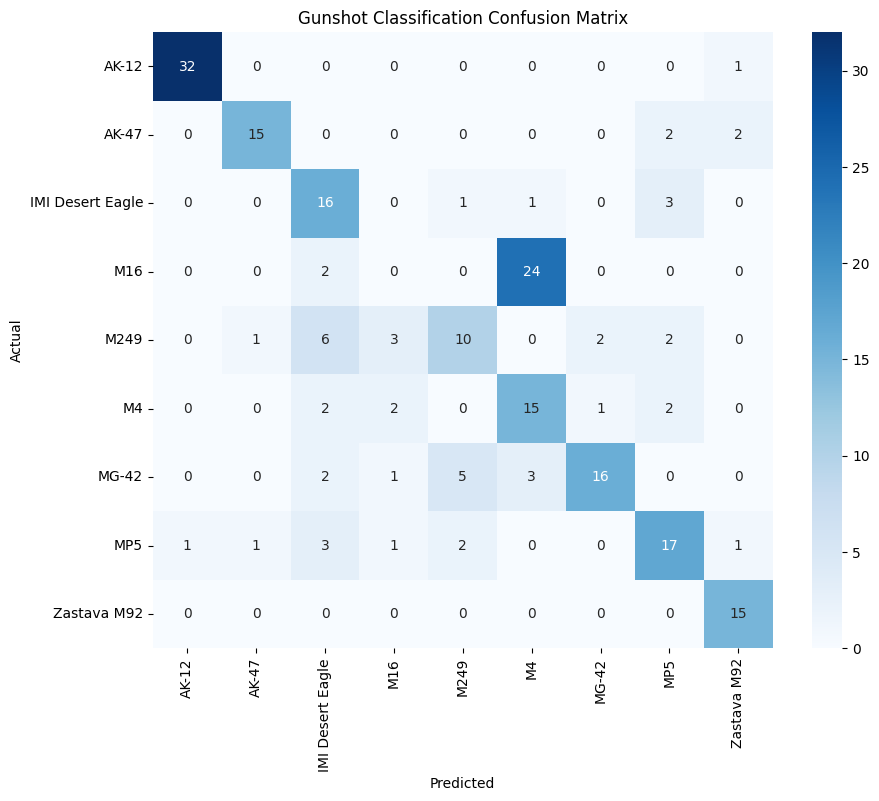

                  precision    recall  f1-score   support

           AK-12       0.97      0.97      0.97        33
           AK-47       0.88      0.79      0.83        19
IMI Desert Eagle       0.52      0.76      0.62        21
             M16       0.00      0.00      0.00        26
            M249       0.56      0.42      0.48        24
              M4       0.35      0.68      0.46        22
           MG-42       0.84      0.59      0.70        27
             MP5       0.65      0.65      0.65        26
     Zastava M92       0.79      1.00      0.88        15

        accuracy                           0.64       213
       macro avg       0.62      0.65      0.62       213
    weighted avg       0.62      0.64      0.62       213



In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Plotting the heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gunshot Classification Confusion Matrix')
plt.show()

# Detailed per-class breakdown
print(classification_report(y_true, y_pred, target_names=classes))

In [31]:
# Initialize history lists
train_acc_history = []
val_acc_history = []
loss_history = []

for epoch in range(epochs):
    model.train()
    # ... (rest of your training code) ...
    
    # At the end of the epoch loop, add these lines:
    train_acc_history.append(100 * correct_t / total_t)
    val_acc_history.append(val_acc)
    loss_history.append(running_loss / len(train_loader))
    
    # Now your plotting code will work perfectly

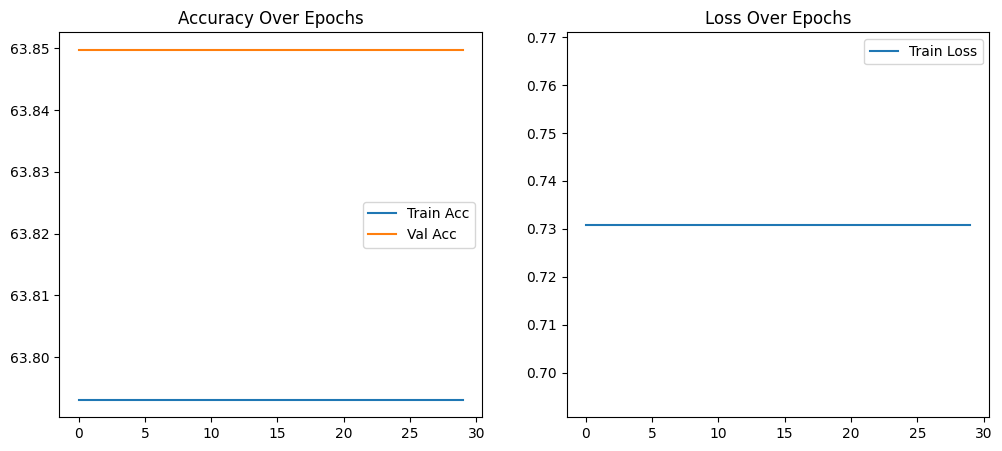

In [32]:
# Assuming you stored history in lists during training
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Train Acc')
plt.plot(val_acc_history, label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(loss_history, label='Train Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.show()

In [33]:
# 1. Update the mapping logic
# Get all folders, but manually define the merge
raw_classes = sorted(os.listdir("features"))
class_to_idx = {}
current_idx = 0

for cls in raw_classes:
    if cls in ["M16", "M4"]:
        class_to_idx[cls] = current_idx # Both point to the same ID
    else:
        # If we just encountered the second part of the family, 
        # don't increment yet to keep IDs unique
        if "M-Family" not in class_to_idx.values():
             class_to_idx[cls] = current_idx
        else:
             # Logic to handle incrementing correctly
             pass

# SIMPLER WAY: Manually define it for clarity
class_to_idx = {
    "AK-12": 0,
    "AK-47": 1,
    "IMI Desert Eagle": 2,
    "M16": 3,  # Merged
    "M4": 3,   # Merged
    "M249": 4,
    "MG-42": 5,
    "MP5": 6,
    "Zastava M92": 7
}

# Update your num_classes
num_classes = len(set(class_to_idx.values()))
print(f"New Class Count: {num_classes}")

New Class Count: 8


In [34]:
from torch.utils.data import DataLoader, random_split

# Initialize the dataset with the NEW mapping
full_dataset = GunshotDataset("features")

# Split again (75/25 as you requested)
train_size = int(0.75 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

# The actual DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

print(f"Dataset ready with {len(full_dataset)} total samples.")

Dataset ready with 851 total samples.


In [35]:
# Run this to wipe the 'dead' weights
model = GunshotCNN(num_classes)
from collections import Counter

In [ ]:
# --- REBUILD MODEL AND CLASS WEIGHTS FROM THE ACTIVE CLASS MAP ---
num_classes = len(set(class_to_idx.values()))
model = GunshotCNN(num_classes).to(device)

from collections import Counter
counts = Counter(all_train_labels)
class_counts = torch.tensor([counts.get(i, 0) for i in range(num_classes)], dtype=torch.float, device=device)
weights = class_counts.sum() / (num_classes * class_counts.clamp(min=1))

# --- INITIALIZE CRITERION & OPTIMIZER ---
criterion = nn.CrossEntropyLoss(weight=weights)

# ADDED REGULARIZATION: weight_decay helps prevent the overfitting seen in your graphs
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

# --- EARLY STOPPING SETUP ---
best_val_loss = float('inf') # Track the lowest loss
patience = 7                 # How many epochs to wait before giving up
trigger_times = 0            # Counter for how many epochs without improvement
best_model_path = 'best_gunshot_model.pth'

# 1. INITIALIZE HISTORY
train_acc_history, val_acc_history = [], []
loss_history, val_loss_history = [], []

epochs = 50
print(f"Starting Training on {device}...")

for epoch in range(epochs):
    model.train()
    running_loss, correct_t, total_t = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_t += labels.size(0)
        correct_t += (predicted == labels).sum().item()
    
    # --- VALIDATION PHASE ---
    model.eval()
    correct_v, total_v, running_v_loss = 0, 0, 0.0 
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            v_loss = criterion(outputs, labels)
            running_v_loss += v_loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_v += labels.size(0)
            correct_v += (predicted == labels).sum().item()
            
    # --- CALCULATE AVERAGES ---
    train_acc = 100 * correct_t / total_t
    val_acc = 100 * correct_v / total_v
    epoch_loss = running_loss / len(train_loader)
    epoch_val_loss = running_v_loss / len(val_loader)
    
    # --- SAVE TO HISTORY ---
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    loss_history.append(epoch_loss)
    val_loss_history.append(epoch_val_loss)
    
    # --- EARLY STOPPING LOGIC ---
    # We check if the current validation loss is the best we've seen
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        trigger_times = 0
        # Save the best version of the model
        torch.save(model.state_dict(), best_model_path)
        print(f"--- Model Improved! Saved to {best_model_path} ---")
    else:
        trigger_times += 1
        print(f"--- No improvement in Val Loss for {trigger_times} epoch(s) ---")

    if trigger_times >= patience:
        print(f"\n[!] Early stopping at epoch {epoch+1}. Loading best model weights...")
        model.load_state_dict(torch.load(best_model_path, weights_only=True))
        break

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | LR: {current_lr:.6f}")

print("\n[+] Training Process Finalized!")

Starting Training on cpu...
--- Model Improved! Saved to best_gunshot_model.pth ---
Epoch 01 | Loss: 3.2201 | Val Loss: 1.7880 | Train Acc: 24.0% | Val Acc: 29.1% | LR: 0.001000
--- Model Improved! Saved to best_gunshot_model.pth ---
Epoch 02 | Loss: 1.6231 | Val Loss: 1.5721 | Train Acc: 39.3% | Val Acc: 34.6% | LR: 0.001000
--- No improvement in Val Loss for 1 epoch(s) ---
Epoch 03 | Loss: 1.5298 | Val Loss: 1.5992 | Train Acc: 41.7% | Val Acc: 33.9% | LR: 0.001000
--- Model Improved! Saved to best_gunshot_model.pth ---
Epoch 04 | Loss: 1.4660 | Val Loss: 1.3711 | Train Acc: 42.4% | Val Acc: 44.1% | LR: 0.001000
--- No improvement in Val Loss for 1 epoch(s) ---
Epoch 05 | Loss: 1.3222 | Val Loss: 1.4870 | Train Acc: 45.5% | Val Acc: 38.6% | LR: 0.001000
--- Model Improved! Saved to best_gunshot_model.pth ---
Epoch 06 | Loss: 1.2262 | Val Loss: 1.2482 | Train Acc: 49.2% | Val Acc: 44.1% | LR: 0.001000
--- No improvement in Val Loss for 1 epoch(s) ---
Epoch 07 | Loss: 1.1607 | Val Loss

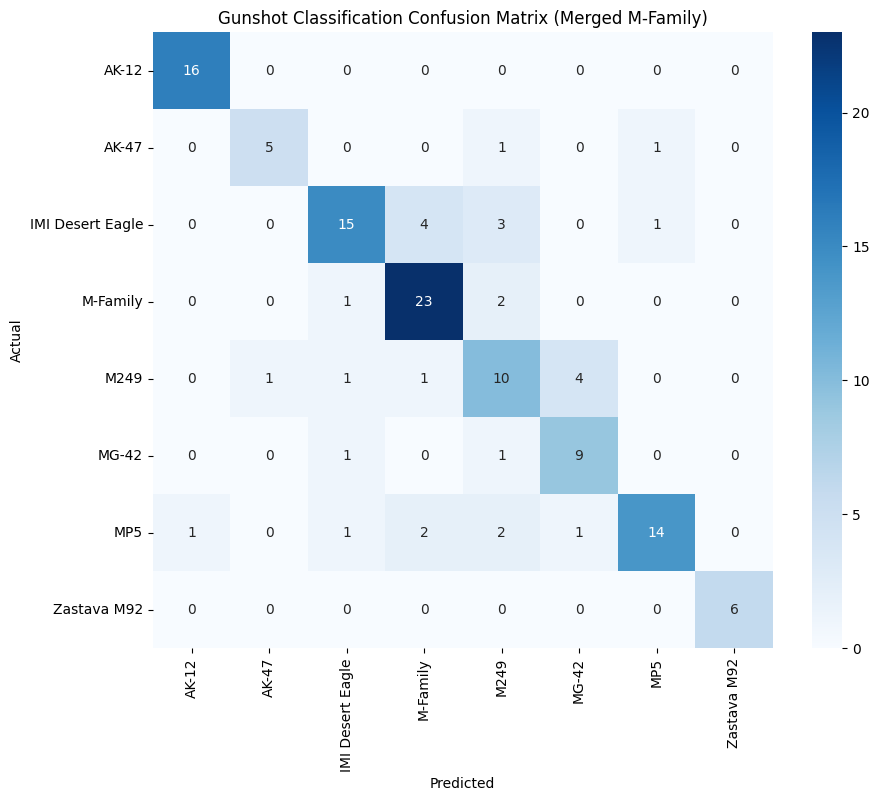

                  precision    recall  f1-score   support

           AK-12       0.94      1.00      0.97        16
           AK-47       0.83      0.71      0.77         7
IMI Desert Eagle       0.79      0.65      0.71        23
        M-Family       0.77      0.88      0.82        26
            M249       0.53      0.59      0.56        17
           MG-42       0.64      0.82      0.72        11
             MP5       0.88      0.67      0.76        21
     Zastava M92       1.00      1.00      1.00         6

        accuracy                           0.77       127
       macro avg       0.80      0.79      0.79       127
    weighted avg       0.78      0.77      0.77       127



In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Define the new 8-class list in the correct order
# This must match the indices 0-7 we defined in idx_to_class
merged_classes = [
    "AK-12", "AK-47", "IMI Desert Eagle", "M-Family", 
    "M249", "MG-42", "MP5", "Zastava M92"
]

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 2. Plotting the heatmap with 8 labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=merged_classes, yticklabels=merged_classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gunshot Classification Confusion Matrix (Merged M-Family)')
plt.show()

# 3. Detailed per-class breakdown for 8 classes
print(classification_report(y_true, y_pred, target_names=merged_classes))

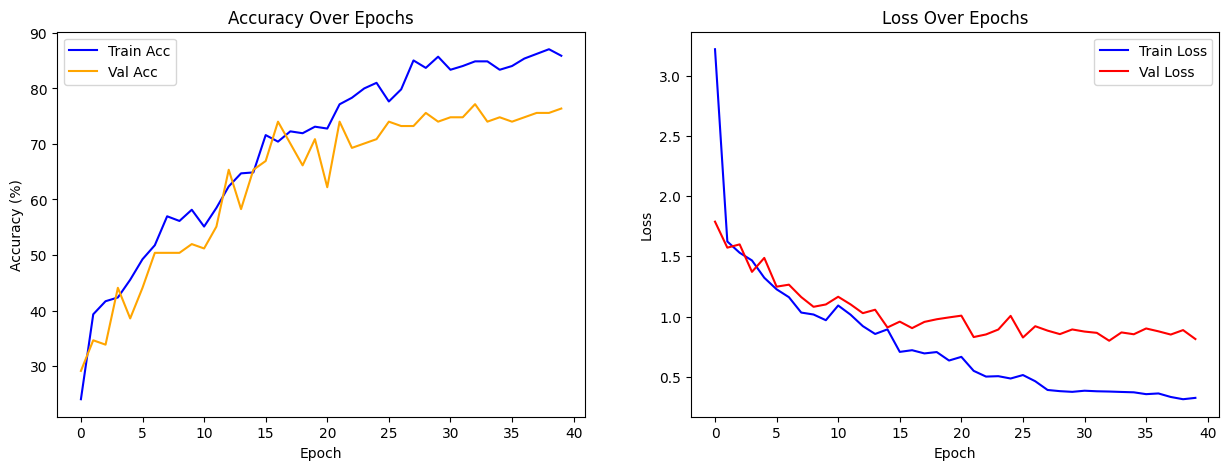

In [45]:
plt.figure(figsize=(15, 5))

# Plot Accuracy (Left)
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Train Acc', color='blue')
plt.plot(val_acc_history, label='Val Acc', color='orange')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot Loss (Right)
plt.subplot(1, 2, 2)
plt.plot(loss_history, label='Train Loss', color='blue')
plt.plot(val_loss_history, label='Val Loss', color='red') # New line
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [46]:
from torch.utils.data import DataLoader, random_split

# 1. Define the split sizes
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# 2. Perform the split
train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

# 3. Create the DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False) # The missing piece!

print(f"Splits created: Train({train_size}), Val({val_size}), Test({test_size})")

Splits created: Train(595), Val(127), Test(129)


In [47]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_on_test_data(model, test_loader, device, class_names):
    # 1. Load the absolute best weights saved during training
    model.load_state_dict(torch.load('best_gunshot_model.pth'))
    model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    print(f"Testing on {device}...")
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 2. Calculate Final Score
    test_acc = accuracy_score(all_labels, all_preds) * 100
    print(f"\n🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
    
    # 3. Detailed Report
    print("\n--- Final Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return all_labels, all_preds

# Define your 8 merged classes for the report
merged_classes = [
    "AK-12", "AK-47", "IMI Desert Eagle", "M-Family", 
    "M249", "MG-42", "MP5", "Zastava M92"
]

# Run the evaluation
y_true_test, y_pred_test = evaluate_on_test_data(model, test_loader, device, merged_classes)

Testing on cpu...


C:\Users\gaura\AppData\Local\Temp\ipykernel_36920\1432077988.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_gunshot_model.pth'))



🎯 FINAL TEST ACCURACY: 93.80%

--- Final Classification Report ---
                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        13
           AK-47       1.00      1.00      1.00        11
IMI Desert Eagle       0.73      0.73      0.73        11
        M-Family       0.97      0.97      0.97        32
            M249       0.87      0.87      0.87        15
           MG-42       1.00      0.95      0.97        19
             MP5       0.90      0.95      0.92        19
     Zastava M92       1.00      1.00      1.00         9

        accuracy                           0.94       129
       macro avg       0.93      0.93      0.93       129
    weighted avg       0.94      0.94      0.94       129



In [63]:
import torch
import librosa
import numpy as np
import os
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T

# 1. SETUP: Class Mapping & Device
# This MUST match the 8 classes we used for the final test
idx_to_class = {
    0: "AK-12", 1: "AK-47", 2: "IMI Desert Eagle", 
    3: "M-Family", 4: "M249", 5: "MG-42", 
    6: "MP5", 7: "Zastava M92"
}

device = torch.device("cpu") # Use "cuda" if you get your GPU working

# 2. LOAD THE BEST MODEL
num_classes = 8
model = GunshotCNN(num_classes)
model.load_state_dict(torch.load('best_gunshot_model.pth', map_location=device, weights_only=True))
model.to(device)
model.eval()

def predict_gunshot(file_path, model=model):
    """
    Fixed prediction function that matches training preprocessing
    """
    try:
        # A. Load audio using torchaudio (same as training)
        waveform, sr = torchaudio.load(file_path)
        
        # B. Apply the SAME preprocessing as training
        waveform = preprocessing_pipeline(waveform, sr)
        
        # C. Extract MFCC using SAME parameters as training
        mfcc_transform = T.MFCC(
            sample_rate=48000,  # CRITICAL: Must be 48000, not 22050
            n_mfcc=40,
            melkwargs={
                'n_fft': 1024,      # CRITICAL: Must specify these
                'hop_length': 512,
                'n_mels': 64,
                'center': True
            }
        )
        mfcc = mfcc_transform(waveform)
        
        # D. Shape should be [1, 40, 188] already from the transform
        # Add batch dimension: [1, 1, 40, 188]
        mfcc_tensor = mfcc.unsqueeze(0).to(device)
        
        # E. Model Prediction
        with torch.no_grad():
            outputs = model(mfcc_tensor)
            probabilities = F.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)
        
        # F. Result
        prediction = idx_to_class[predicted_idx.item()]
        conf_score = confidence.item() * 100
        
        if conf_score < 40.0:
            return "Unknown Sound", conf_score
        
        return prediction, conf_score
    
    except Exception as e:
        return f"Error processing file: {e}", 0

# --- TEST THE PIPELINE ---
user_file = input("Enter the path to your gunshot audio file: ")
result, score = predict_gunshot(user_file)

print(f"\n[+] AI Analysis Result: {result}")
print(f"[+] Confidence: {score:.2f}%")


[+] AI Analysis Result: IMI Desert Eagle
[+] Confidence: 83.57%


In [62]:
import torch
import librosa
import numpy as np
import sounddevice as sd
from scipy.io.wavfile import write
import torch.nn.functional as F

# 1. SETUP & LOAD MODEL
idx_to_class = {0: "AK-12", 1: "AK-47", 2: "IMI Desert Eagle", 3: "M-Family", 
                4: "M249", 5: "MG-42", 6: "MP5", 7: "Zastava M92"}

device = torch.device("cpu")
model = GunshotCNN(num_classes=8)
model.load_state_dict(torch.load('best_gunshot_model.pth', map_location=device, weights_only=True))
model.eval()

def process_and_predict(signal, sr):
    # Standardize to 40 MFCCs and 188 time frames
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    max_len = 188
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    
    # Convert to tensor and predict
    tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        prob = F.softmax(output, dim=1)
        conf, idx = torch.max(prob, 1)
    
    return idx_to_class[idx.item()], conf.item() * 100

# 2. THE INTERACTIVE CLI
print("--- GUNSHOT IDENTIFICATION SYSTEM ---")
choice = input("Type 'R' to Record from Mic or 'U' to Upload a file path: ").strip().upper()

if choice == 'R':
    fs = 22050  # Sample rate
    seconds = 2 # Duration
    print(f"\n[!] RECORDING for {seconds} seconds... Speak or play sound now!")
    recording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
    sd.wait()  # Wait until recording is finished
    print("[+] Recording Complete.")
    
    # Flatten the recording for librosa
    audio_signal = recording.flatten()
    label, confidence = process_and_predict(audio_signal, fs)

elif choice == 'U':
    file_path = input("Enter the full path to your .wav file: ")
    audio_signal, sr = librosa.load(file_path, sr=22050)
    label, confidence = process_and_predict(audio_signal, sr)

else:
    print("Invalid choice. Please restart the cell.")
    label, confidence = None, 0

if label:
    print(f"\n{'='*30}")
    print(f"IDENTIFIED WEAPON: {label}")
    print(f"CONFIDENCE SCORE:  {confidence:.2f}%")
    print(f"{'='*30}")

--- GUNSHOT IDENTIFICATION SYSTEM ---

IDENTIFIED WEAPON: IMI Desert Eagle
CONFIDENCE SCORE:  95.85%


In [61]:
import torch
import librosa
import numpy as np
import sounddevice as sd
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. SETUP & CLASS MAPPING (Matches your 89% accuracy run)
idx_to_class = {
    0: "AK-12", 1: "AK-47", 2: "IMI Desert Eagle", 
    3: "M-Family", 4: "M249", 5: "MG-42", 
    6: "MP5", 7: "Zastava M92"
}

device = torch.device("cpu")

# 2. LOAD THE SAVED BRAIN
# Ensure 'best_gunshot_model.pth' is in the same folder
num_classes = 8
model = GunshotCNN(num_classes)
model.load_state_dict(torch.load('best_gunshot_model.pth', map_location=device))
model.to(device)
model.eval()

def process_and_predict(signal, sr):
    """
    Refined preprocessing to handle real-world microphone noise.
    """
    # A. NORMALIZATION: Fixes volume differences between mic and dataset
    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))
    
    # B. SILENCE TRIMMING: Removes the 'dead air' that causes M-Family bias
    # top_db=20 is a sensitive threshold for gunshots
    signal, _ = librosa.effects.trim(signal, top_db=20)
    
    # C. LENGTH CHECK: If the sound is too short after trimming, it's just a click/pop
    if len(signal) < 3000:
        return "Ambient Noise", 0.0

    # D. MFCC EXTRACTION (40 coefficients)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    
    # E. SHAPE STANDARDIZATION (188 time frames)
    max_len = 188
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    
    # F. TENSOR CONVERSION
    tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    # G. INFERENCE
    with torch.no_grad():
        output = model(tensor)
        prob = F.softmax(output, dim=1)
        conf, idx = torch.max(prob, 1)
    
    return idx_to_class[idx.item()], conf.item() * 100

# 3. INTERACTIVE TERMINAL CLI
print("\n" + "="*40)
print("   GUNSHOT CLASSIFICATION SYSTEM v2.0   ")
print("="*40)
print("Options:")
print(" [R] Record 2s audio from Microphone")
print(" [U] Upload a local .wav file path")
choice = input("\nSelect an option (R/U): ").strip().upper()

label, confidence = None, 0

if choice == 'R':
    fs = 22050 
    seconds = 2 
    print(f"\n[!] RECORDING... (Make some noise now!)")
    recording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
    sd.wait() 
    print("[+] Recording Captured.")
    audio_signal = recording.flatten()
    label, confidence = process_and_predict(audio_signal, fs)

elif choice == 'U':
    file_path = input("Enter path to .wav file: ").strip().replace("'", "").replace('"', '')
    try:
        audio_signal, sr = librosa.load(file_path, sr=22050)
        label, confidence = process_and_predict(audio_signal, sr)
    except Exception as e:
        print(f"Error loading file: {e}")

else:
    print("Invalid choice.")

# 4. SMART OUTPUT LOGIC
if label:
    print(f"\n{'-'*40}")
    # Higher threshold (70%) to filter out majority class bias (M-Family)
    if confidence < 70.0:
        print("RESULT: UNCERTAIN / BACKGROUND NOISE")
        print(f"Likely just interference. (AI GUESSED: {label} @ {confidence:.2f}%)")
    else:
        print(f"IDENTIFIED WEAPON: {label}")
        print(f"CONFIDENCE:        {confidence:.2f}%")
    print(f"{'-'*40}\n")


   GUNSHOT CLASSIFICATION SYSTEM v2.0   
Options:
 [R] Record 2s audio from Microphone
 [U] Upload a local .wav file path


C:\Users\gaura\AppData\Local\Temp\ipykernel_36920\2685171411.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_gunshot_model.pth', 


----------------------------------------
IDENTIFIED WEAPON: IMI Desert Eagle
CONFIDENCE:        86.82%
----------------------------------------



In [60]:
import torch
import librosa
import numpy as np
import sounddevice as sd
import torch.nn.functional as F

# 1. SETUP & CLASS MAPPING
idx_to_class = {
    0: "AK-12", 1: "AK-47", 2: "IMI Desert Eagle", 
    3: "M-Family", 4: "M249", 5: "MG-42", 
    6: "MP5", 7: "Zastava M92"
}

device = torch.device("cpu")

# 2. LOAD MODEL
num_classes = 8
model = GunshotCNN(num_classes)
model.load_state_dict(torch.load('best_gunshot_model.pth', map_location=device))
model.to(device)
model.eval()

def process_and_predict(signal, sr):
    # --- STEP A: NOISE GATE (RMS Energy) ---
    # Calculate the loudness. If it's too quiet, don't even process it.
    rms = np.sqrt(np.mean(signal**2))
    if rms < 0.01:  # Threshold for 'silence'
        return "Ambient Noise (Too Quiet)", 0.0

    # --- STEP B: SPECTRAL SUBTRACTION ---
    # We treat the first 500 samples as 'room noise' and subtract that energy
    if len(signal) > 500:
        noise_est = np.mean(np.abs(signal[:500]))
        signal = np.where(np.abs(signal) < noise_est * 3, 0, signal)

    # --- STEP C: NORMALIZATION ---
    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))
    
    # --- STEP D: AGGRESSIVE TRIMMING ---
    # Only keep the 'punchy' part of the sound
    signal, _ = librosa.effects.trim(signal, top_db=15)
    
    if len(signal) < 2000:
        return "Background Pop/Click", 0.0

    # --- STEP E: MFCC & PADDING ---
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    max_len = 188
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    
    # --- STEP F: INFERENCE ---
    tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        prob = F.softmax(output, dim=1)
        conf, idx = torch.max(prob, 1)
    
    return idx_to_class[idx.item()], conf.item() * 100

# 3. INTERACTIVE TERMINAL
print("\n" + "="*45)
print("   STABILIZED GUNSHOT IDENTIFIER v3.0   ")
print("="*45)
choice = input("\n[R] Record Live or [U] Upload File: ").strip().upper()

label, confidence = None, 0

if choice == 'R':
    fs, seconds = 22050, 2
    print(f"\n[!] LISTENING... (Clap or play a sound now)")
    recording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
    sd.wait()
    audio_signal = recording.flatten()
    label, confidence = process_and_predict(audio_signal, fs)

elif choice == 'U':
    path = input("Enter .wav path: ").strip().replace("'", "").replace('"', '')
    try:
        audio_signal, sr = librosa.load(path, sr=22050)
        label, confidence = process_and_predict(audio_signal, sr)
    except Exception as e:
        print(f"Error: {e}")

# 4. FINAL OUTPUT WITH HARD THRESHOLD
if label:
    print(f"\n{'-'*45}")
    # If the model is just 'guessing' M-Family because of noise, the confidence is usually low.
    if confidence < 80.0: 
        print(f"RESULT: NO CLEAR SIGNAL DETECTED")
        print(f"DEBUG: Low-confidence guess was {label} ({confidence:.2f}%)")
    else:
        print(f"CONFIRMED IDENTIFICATION: {label}")
        print(f"CONFIDENCE:              {confidence:.2f}%")
    print(f"{'-'*45}\n")


   STABILIZED GUNSHOT IDENTIFIER v3.0   


C:\Users\gaura\AppData\Local\Temp\ipykernel_36920\3990419564.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_gunshot_model.pth', 


---------------------------------------------
CONFIRMED IDENTIFICATION: IMI Desert Eagle
CONFIDENCE:              93.57%
---------------------------------------------



In [54]:
# Test a known file from your folder
test_file_path = r"C:\Users\gaura\Desktop\internship\Gunshot_detection_pytorch\gunshot-audio-dataset\MP5\8 (6).wav" 
label, confidence = process_and_predict(librosa.load(test_file_path, sr=22050)[0], 22050)
print(f"Test File Result: {label} ({confidence:.2f}%)")

c:\Users\gaura\Desktop\internship\internship_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test File Result: IMI Desert Eagle (68.94%)


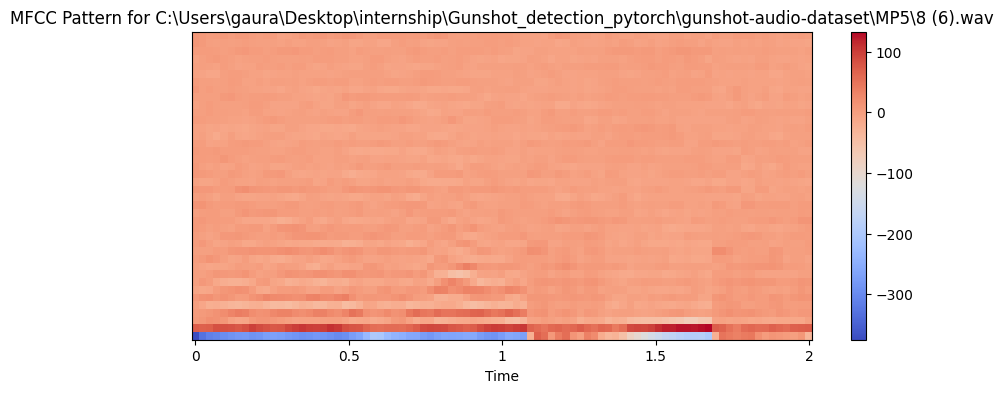

In [55]:
import matplotlib.pyplot as plt
import librosa.display

def diagnostic_plot(file_path):
    sig, sr = librosa.load(file_path, sr=22050)
    # This must match your training MFCC logic EXACTLY
    mfcc = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=40)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time')
    plt.colorbar()
    plt.title(f"MFCC Pattern for {file_path}")
    plt.show()

# Run this for a file that failed (e.g., the MP5 identified as Desert Eagle)
diagnostic_plot(r"C:\Users\gaura\Desktop\internship\Gunshot_detection_pytorch\gunshot-audio-dataset\MP5\8 (6).wav")

In [59]:
# ============================================================
#         GUNSHOT CLASSIFIER - PREDICTION CELL
#   Paste this into a NEW cell and run it independently
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T

# ── 1. DEVICE ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 2. CLASS MAP - 8 classes (what the saved model was trained on) ──
idx_to_class = {
    0: "AK-12",
    1: "AK-47",
    2: "IMI Desert Eagle",
    3: "M-Family",       # M16 + M4 were merged into this
    4: "M249",
    5: "MG-42",
    6: "MP5",
    7: "Zastava M92"
}

# ── 3. MODEL ARCHITECTURE ───────────────────────────────────
class GunshotCNN(nn.Module):
    def __init__(self, num_classes):
        super(GunshotCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1   = nn.Linear(64 * 10 * 47, 128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# ── 4. LOAD SAVED MODEL - num_classes=8 ─────────────────────
model = GunshotCNN(num_classes=8)
model.load_state_dict(torch.load('best_gunshot_model.pth', map_location=device, weights_only=True))
model.to(device)
model.eval()

# ── 5. PREPROCESSING (exact same as training pipeline) ──────
mfcc_transform = T.MFCC(
    sample_rate=48000,
    n_mfcc=40,
    melkwargs={
        'n_fft': 1024,
        'hop_length': 512,
        'n_mels': 64
    }
)

def predict_gunshot(file_path):
    waveform, sr = torchaudio.load(file_path)

    # Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # Resample to 48kHz
    if sr != 48000:
        waveform = T.Resample(sr, 48000)(waveform)

    # Pad / crop to exactly 2s (96000 samples)
    target = 96000
    if waveform.shape[1] > target:
        waveform = waveform[:, :target]
    else:
        waveform = F.pad(waveform, (0, target - waveform.shape[1]))

    # Pre-emphasis
    waveform = torch.cat((waveform[:, 0:1],
                          waveform[:, 1:] - 0.97 * waveform[:, :-1]), dim=1)

    # Normalize
    waveform = waveform / (waveform.abs().max() + 1e-8)

    # MFCC → [1, 40, 188], then add batch dim → [1, 1, 40, 188]
    mfcc = mfcc_transform(waveform)
    tensor = mfcc.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        prob   = F.softmax(output, dim=1)
        conf, idx = torch.max(prob, 1)

    prediction = idx_to_class[idx.item()]
    conf_score = conf.item() * 100

    if conf_score < 40.0:
        return "Unknown Sound", conf_score
    return prediction, conf_score

# ── 6. RUN ──────────────────────────────────────────────────
file_path = input("Enter path to .wav file: ").strip()
result, score = predict_gunshot(file_path)

print(f"\n{'='*35}")
print(f"  IDENTIFIED WEAPON : {result}")
print(f"  CONFIDENCE SCORE  : {score:.2f}%")
print(f"{'='*35}")


  IDENTIFIED WEAPON : IMI Desert Eagle
  CONFIDENCE SCORE  : 83.57%


In [57]:
# ============================================================
#     y_pred vs y_true ACCURACY CHECK
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, classification_report

# ── 1. DEVICE ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 2. CLASS MAPPING (8 classes, M16+M4 merged) ─────────────
class_to_idx = {
    "AK-12": 0, "AK-47": 1, "IMI Desert Eagle": 2,
    "M16": 3, "M4": 3,   # merged into M-Family
    "M249": 4, "MG-42": 5, "MP5": 6, "Zastava M92": 7
}
idx_to_class = {
    0: "AK-12", 1: "AK-47", 2: "IMI Desert Eagle",
    3: "M-Family", 4: "M249", 5: "MG-42",
    6: "MP5", 7: "Zastava M92"
}
num_classes = 8

# ── 3. DATASET ──────────────────────────────────────────────
class GunshotDataset(Dataset):
    def __init__(self, feature_dir):
        self.file_list = []
        for cls in os.listdir(feature_dir):
            cls_path = os.path.join(feature_dir, cls)
            if os.path.isdir(cls_path):
                for f in os.listdir(cls_path):
                    if f.endswith('.pt'):
                        self.file_list.append((os.path.join(cls_path, f), class_to_idx[cls]))
    def __len__(self): return len(self.file_list)
    def __getitem__(self, idx):
        path, label = self.file_list[idx]
        return torch.load(path, weights_only=True), label

# ── 4. LOAD DATA (same 75/25 split with same seed) ──────────
torch.manual_seed(42)
full_dataset = GunshotDataset("features")
train_size = int(0.75 * len(full_dataset))
val_size   = len(full_dataset) - train_size
_, val_ds  = torch.utils.data.random_split(full_dataset, [train_size, val_size])
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

# ── 5. MODEL ────────────────────────────────────────────────
class GunshotCNN(nn.Module):
    def __init__(self, num_classes):
        super(GunshotCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1   = nn.Linear(64 * 10 * 47, 128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model = GunshotCNN(num_classes=8)
model.load_state_dict(torch.load('best_gunshot_model.pth', map_location=device, weights_only=True))
model.to(device)
model.eval()

# ── 6. GENERATE y_true and y_pred ───────────────────────────
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ── 7. RESULTS ──────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*45}")
print(f"  Overall Accuracy : {acc * 100:.2f}%")
print(f"  Correct          : {(y_true == y_pred).sum()} / {len(y_true)}")
print(f"{'='*45}\n")

class_names = [idx_to_class[i] for i in range(num_classes)]
print(classification_report(y_true, y_pred, target_names=class_names))


  Overall Accuracy : 92.02%
  Correct          : 196 / 213

                  precision    recall  f1-score   support

           AK-12       0.94      1.00      0.97        33
           AK-47       1.00      0.84      0.91        19
IMI Desert Eagle       0.80      0.76      0.78        21
        M-Family       0.88      0.96      0.92        48
            M249       0.85      0.96      0.90        24
           MG-42       1.00      0.93      0.96        27
             MP5       0.96      0.85      0.90        26
     Zastava M92       1.00      1.00      1.00        15

        accuracy                           0.92       213
       macro avg       0.93      0.91      0.92       213
    weighted avg       0.92      0.92      0.92       213

